/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

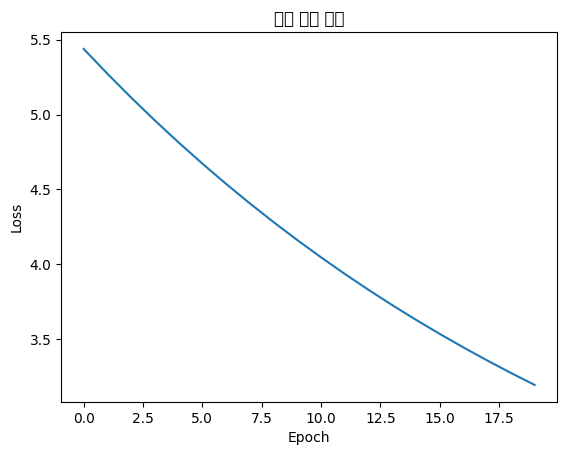

In [4]:
#라이브러리 임포트
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim


#데이터셋 정의
x_data = [[1,2],[3,4],[5,5],[7,8]]
y_data = [[1],[2],[3],[4]]

x_tensor = torch.tensor(x_data, dtype=torch.float32)
y_tensor = torch.tensor(y_data, dtype=torch.float32)
#모델정의 (레이어 + 활성화 함수 + 순전파 )
class MyNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(2,4),
        nn.ReLU(),
        nn.Linear(4,1)
    )

  def forward(self, x):
    return self.layers(x)
#모델, 손실함수 및 옵티마이저 정의
model = MyNN()
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
#학습 루프

num_epochs = 20
losses = []

for i in range(num_epochs):
  #가중치 초기화
  optimizer.zero_grad()
  #예측값 구하기
  y_pred = model(x_tensor)
  #손실 계산
  loss = loss_fn(y_pred, y_tensor)
  #역전파
  loss.backward()
  #가중치 업데이트
  optimizer.step()
  #손실값 저장
  losses.append(loss.item())
#결과 시각화
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('학습 손실 변화')
plt.show()

In [7]:
#라이브러리 임포트

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#데이터셋 불러오기
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_dataset = datasets.MNIST(root='./data',train=False,download=True,transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=False)

#모델, 손실함수 및 옵티마이저 정의
#학습루프
#결과 시각화


In [9]:
class MyMNISTNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64,10)
    )


  def forward(self, x):
    x = x.view(-1, 784)
    return self.layers(x)




In [15]:
model = MyMNISTNN()

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
#파라미서 함수는 모델 안에서 학습 가능한 가중치를 반환함.

In [ ]:
num_epochs = 10
for i in range(num_epochs):
  #배치단위로 불러오기
  for images, labels in train_loader:
      #가중치 초기화
      optimizer.zero_grad()
      #예측값 계산
      y_pred = model(images)
      #손실값 정의
      loss = loss_fn(y_pred, labels)
      #경사하강법
      loss.backward()
      #다음스탭
      optimizer.step()
  # epoch마다 출력
  print(f'Epoch {i+1}/{num_epochs}, Loss: {loss.item():.4f}')


In [17]:
correct = 0
total = 0
with torch.no_grad():
  for images, labels in test_loader:
    #예측값
    y_pred = model(images)
    #가장 높은 확률의 숫자 선택
    predicted = y_pred.argmax(1) #0은 세로, 1은 가로
    #전체 개수 누적
    total += labels.size(0)
    #맞춘 개수 누적
    correct += (predicted == labels).sum().item()

print(f'정확도: {100 * correct / total:.2f}%')

정확도: 98.01%


In [18]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설치
!apt-get install -y fonts-nanum
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (8,384 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


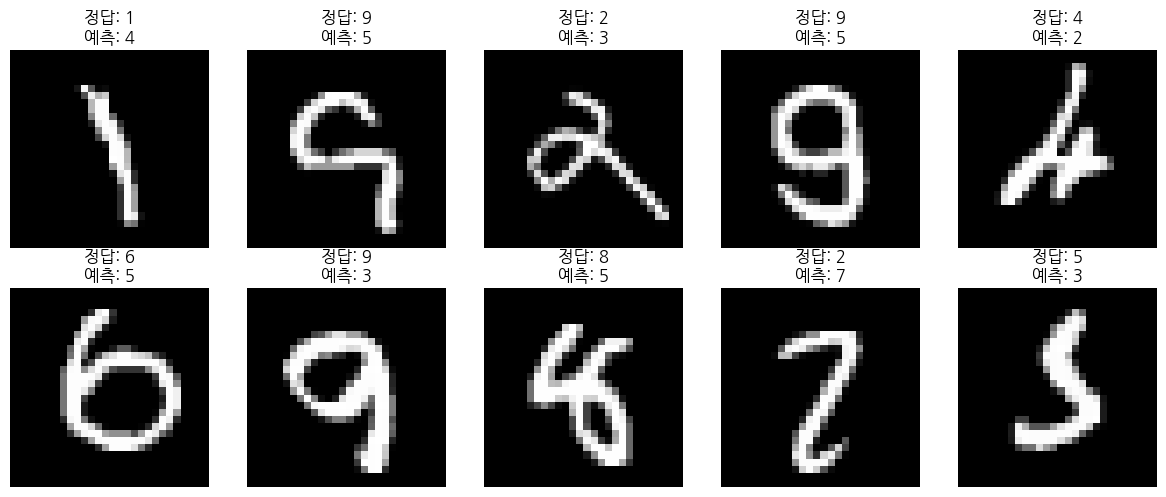

In [19]:
wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        y_pred = model(images)
        predicted = y_pred.argmax(1)

        wrong_mask = (predicted != labels)
        wrong_images.extend(images[wrong_mask])
        wrong_preds.extend(predicted[wrong_mask])
        wrong_labels.extend(labels[wrong_mask])

# 틀린 이미지 10개 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f'정답: {wrong_labels[i].item()}\n예측: {wrong_preds[i].item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()